# 03 Evaluation and Plots

This notebook loads trained PPO policies and/or evaluation outputs and produces summary metrics and plots for the experimental report.

It demonstrates:
- loading saved Stable-Baselines3 PPO models
- checking archive and log contents
- running a small evaluation loop
- generating a comparison table and simple plots

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT / "src"))

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

from f1_rl_safety.f1_env import F1RaceEnv

## Locate saved PPO models

In [4]:
models_dir = ROOT / "models"
model_files = sorted(models_dir.glob("*.zip")) if models_dir.exists() else []

print("Model files:")
for f in model_files:
    print("-", f.name)

Model files:
- ppo_demo_notebook.zip
- ppo_rulebook.zip
- ppo_safe.zip
- ppo_unconstrained.zip


## Load models

This cell attempts to load all available PPO model zip files.

In [5]:
loaded_models = {}

for model_path in model_files:
    try:
        model = PPO.load(str(model_path), device="cpu")
        loaded_models[model_path.stem] = model
        print("Loaded:", model_path.name)
    except Exception as e:
        print("Failed:", model_path.name, "|", e)

print("Loaded models:", list(loaded_models.keys()))

Loaded: ppo_demo_notebook.zip
Loaded: ppo_rulebook.zip
Loaded: ppo_safe.zip
Loaded: ppo_unconstrained.zip
Loaded models: ['ppo_demo_notebook', 'ppo_rulebook', 'ppo_safe', 'ppo_unconstrained']


## Optional evaluation loop

This evaluates each loaded model for a small number of episodes.
If your environment returns custom metrics in `info`, they will be captured where possible.

You may need to adapt the metric keys depending on your environment implementation.

In [6]:
def evaluate_model(model, env, n_episodes=5):
    rows = []
    for ep in range(n_episodes):
        obs, info = env.reset()
        done = False
        truncated = False
        total_reward = 0.0
        last_info = {}

        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            total_reward += reward
            last_info = info if isinstance(info, dict) else {}

        row = {"episode": ep, "total_reward": total_reward}
        if isinstance(last_info, dict):
            for key in [
                "race_time",
                "finish_position",
                "pit_stops",
                "avg_risk",
                "crash",
                "catastrophic",
            ]:
                if key in last_info:
                    row[key] = last_info[key]
        rows.append(row)
    return pd.DataFrame(rows)

In [8]:
RUN_EVAL = True
results = {}

if RUN_EVAL:
    for model_name, model in loaded_models.items():
        env = F1RaceEnv()
        df = evaluate_model(model, env, n_episodes=5)
        results[model_name] = df
        print("\n", model_name)
        display(df.head())
else:
    print("Evaluation skipped.")


 ppo_demo_notebook


,episode,total_reward,crash
0,0,-39.015582,True
1,1,-57.192597,True
2,2,-85.555893,True
3,3,-44.875926,True
4,4,-107.166990,True



 ppo_rulebook


,episode,total_reward,crash
0,0,-28.322925,True
1,1,-29.206704,True
2,2,-20.015511,True
3,3,-25.410114,True
4,4,-66.617514,False



 ppo_safe


,episode,total_reward,crash
0,0,-50.946890,True
1,1,-85.309625,True
2,2,-94.273155,False
3,3,-45.863098,True
4,4,-86.944435,False



 ppo_unconstrained


,episode,total_reward,crash
0,0,-17.174175,True
1,1,-14.745850,True
2,2,-16.292882,True
3,3,-45.309051,True
4,4,-52.524490,False


## Combine evaluation summaries

In [9]:
summary_frames = []

for model_name, df in results.items():
    numeric_cols = [c for c in df.columns if c != "episode"]
    summary = df[numeric_cols].mean(numeric_only=True).to_dict()
    summary["model"] = model_name
    summary_frames.append(summary)

summary_df = pd.DataFrame(summary_frames)
display(summary_df)

,total_reward,crash,model
0,-66.761398,1.0,ppo_demo_notebook
1,-33.914554,0.8,ppo_rulebook
2,-72.667441,0.6,ppo_safe
3,-29.209289,0.8,ppo_unconstrained


## Save evaluation summary

In [10]:
output_dir = ROOT / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

summary_path = output_dir / "notebook_eval_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved summary to:", summary_path)

Saved summary to: /Users/joel_mathew/f1-rl-safety/data/processed/notebook_eval_summary.csv


## Simple plots

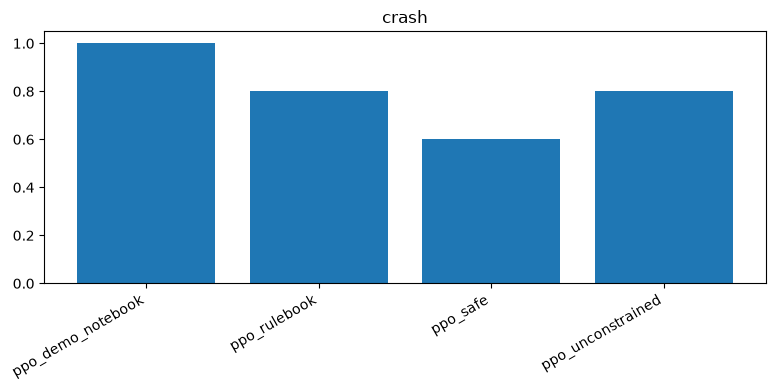

In [11]:
if not summary_df.empty:
    plot_cols = [c for c in ["race_time", "finish_position", "pit_stops", "avg_risk", "crash", "catastrophic"] if c in summary_df.columns]

    for col in plot_cols:
        plt.figure(figsize=(8, 4))
        plt.bar(summary_df["model"], summary_df[col])
        plt.title(col)
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("No summary data available for plotting.")

## Notes

This notebook is intended to support the experimental report by:
- loading trained PPO policies,
- demonstrating evaluation,
- and generating summary tables and plots.

The full evaluation implementation remains in:
- `src/f1_rl_safety/eval_policies.py`